# T-Test
The T-Test is used when the data is normal and the data is a sample of the total data.

In [94]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import math
import pickle
from scipy.stats import norm
from scipy.stats import entropy
import seaborn as sns
import os

- T-Test One Sample

In [95]:
dataset = os.path.join('datasets','orange_trees.csv')
df = pd.read_csv(dataset)
df.head()

,tree_number,oranges
0,1223,305.470796
1,1224,208.357224
2,1225,318.145987
3,1226,274.531146
4,1227,245.627474


<Axes: >

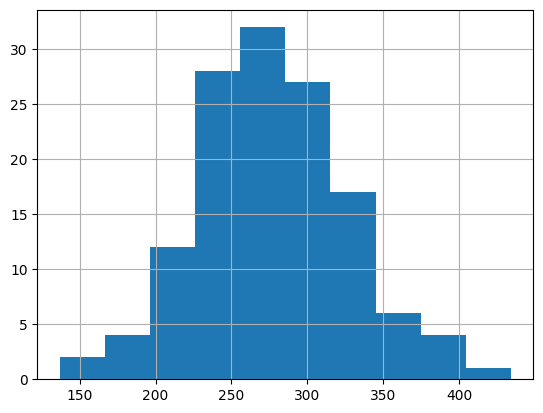

In [96]:
df['oranges'].hist()

Use JensonShannon for compare to normal distribution

In [97]:
def js(p, q):
    p1 = p / np.linalg.norm(p, ord=1)
    q1 = q / np.linalg.norm(q, ord=1)
    m = 0.5 * (p1 + q1)
    r = 0.5 * (entropy(p1, m) + entropy(q1, m))
    return r

In [98]:
norm_data = norm.rvs(size=len(df['oranges']), loc=df['oranges'].mean(), scale=df['oranges'].std())
norm_count, norm_devision = np.histogram(norm_data, bins=100)

In [99]:
count, devision = np.histogram(df['oranges'], bins=100)

In [100]:
js(count, norm_count)

np.float64(0.17798921729440967)

Use histogram plot for compare to normal distribution

C:\Users\Soheil\AppData\Local\Temp\ipykernel_3052\3208757330.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(norm_data)
C:\Users\Soheil\AppData\Local\Temp\ipykernel_3052\3208757330.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['oranges'])


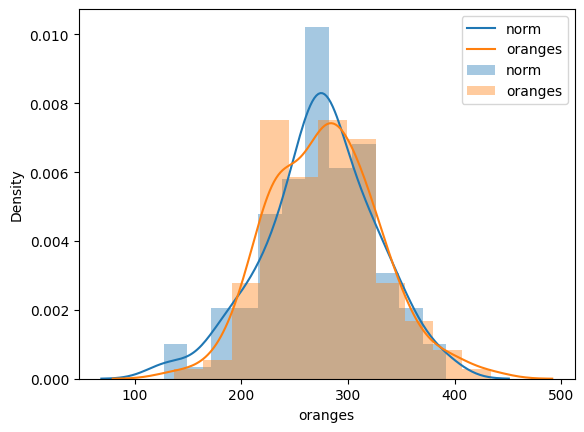

In [101]:
sns.distplot(norm_data)
sns.distplot(df['oranges'])
plt.legend(['norm', 'oranges', 'norm', 'oranges'])

This number is hypothetical -> 271.93 / You can change it and see the result

In [102]:
population_mean = 271.93

In [103]:
stats.ttest_1samp(a=df['oranges'], popmean=population_mean)

TtestResult(statistic=np.float64(1.3413606837344207), pvalue=np.float64(0.18210666026278088), df=np.int64(132))

- T-Test Independent

In [104]:
dataset_ielts_ir = os.path.join('datasets','ielts_ir.csv')
df_ielts_ir = pd.read_csv(dataset_ielts_ir)
dataset_ielts_irq = os.path.join('datasets','ielts_irq.csv')
df_ielts_irq = pd.read_csv(dataset_ielts_irq)

<Axes: >

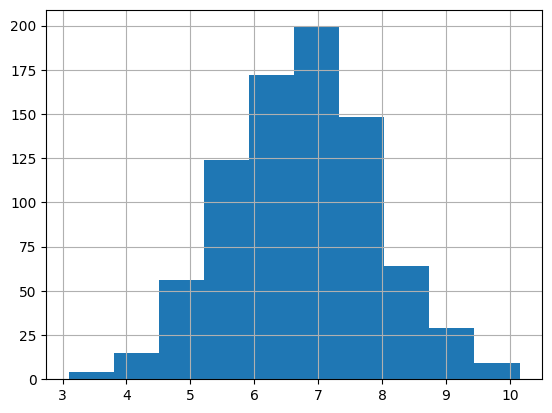

In [105]:
df_ielts_ir['ielts'].hist()

<Axes: >

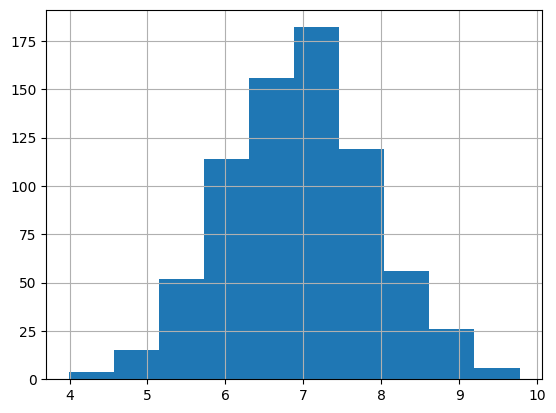

In [106]:
df_ielts_irq['ielts'].hist()

In [107]:
from scipy.stats import shapiro
shapiro(df_ielts_irq['ielts'])

ShapiroResult(statistic=np.float64(0.9986898324675261), pvalue=np.float64(0.878157301316574))

In [108]:
df_ielts_ir.describe()

,student_code,ielts
count,8.200000e+02,820.000000
mean,5.051195e+06,6.747519
std,2.824548e+06,1.147674
min,1.172970e+05,3.094945
25%,2.690282e+06,5.949468
50%,5.260994e+06,6.770676
75%,7.289848e+06,7.497761
max,9.973863e+06,10.150000


In [109]:
df_ielts_irq.describe()

,student_code,ielts
count,7.300000e+02,730.000000
mean,4.941690e+06,6.941447
std,2.771198e+06,0.943821
min,1.172970e+05,3.988457
25%,2.644577e+06,6.282705
50%,5.018210e+06,6.946460
75%,7.153068e+06,7.561849
max,9.966460e+06,9.772641


In [110]:
stats.ttest_ind(a=df_ielts_ir['ielts'], b=df_ielts_irq['ielts'])

TtestResult(statistic=np.float64(-3.6069374810014296), pvalue=np.float64(0.0003196736637378235), df=np.float64(1548.0))

- T-Test Relative

In [111]:
dataset = os.path.join('datasets','weights_change.csv')
df = pd.read_csv(dataset)
df.head()

,weight_before,weight_after
0,71.467888,73.965979
1,68.138362,64.829687
2,72.259526,62.792359
3,76.849401,76.782419
4,67.635565,72.078769


array([[<Axes: title={'center': 'weight_before'}>,
        <Axes: title={'center': 'weight_after'}>]], dtype=object)

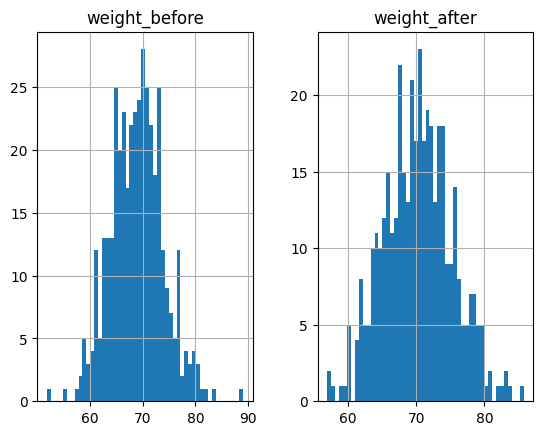

In [112]:
df.hist(bins=50)

In [113]:
df.describe()

,weight_before,weight_after
count,410.000000,410.000000
mean,68.946168,70.297810
std,5.007353,4.992076
min,51.867684,57.006987
25%,65.439872,66.830448
50%,69.106005,70.262523
75%,72.142028,73.595429
max,89.065252,85.744306


In [114]:
stats.ttest_rel(a=df['weight_before'], b=df['weight_after'])

TtestResult(statistic=np.float64(-3.833125480231282), pvalue=np.float64(0.00014643438582166005), df=np.int64(409))

In [115]:
stats.ttest_ind(a=df['weight_before'], b=df['weight_after'])

TtestResult(statistic=np.float64(-3.8707304840033845), pvalue=np.float64(0.00011715492857272653), df=np.float64(818.0))